In [1]:
import os
import logging

# 1. Set environment variables BEFORE importing ultralytics
os.environ["YOLO_VERBOSE"] = "False"

# 2. Configure logging to only show warnings or errors
# This specifically targets the "Header" spam
logging.getLogger("ultralytics").setLevel(logging.ERROR)

# 🚦 YOLO Object Detection — Dataset Preparation & Training Pipeline

This notebook covers the complete workflow for preparing and training a YOLO-based object detection model, with a strong focus on data quality and class balance to improve generalization.

## 📦 Dataset Preparation Strategy

The following steps are applied before training:

- Use of official train/test split provided with the dataset  
- Validation set created from training data to avoid test leakage  
- Heavy-class deduplication (undersampling) using perceptual hashing (pHash)  
- Targeted data augmentation for rare classes  
- Bounding-box–safe Albumentations pipeline compatible with YOLO format  

These steps aim to reduce redundancy, mitigate class imbalance, and increase effective dataset diversity.

## 🧠 Model Training

- Model: YOLO (pretrained weights, fine-tuned on custom dataset)  
- Transfer learning used for faster convergence and better feature reuse  
- Early stopping and mosaic scheduling applied to prevent overfitting  

## 📊 Evaluation & Inference

- Validation metrics: mAP, Precision, Recall  
- Confusion matrix and PR/F1 curves generated using Ultralytics validation tools (`output/runs/detect/train`)  
- Inference pipeline included for qualitative result inspection  

---

This notebook is intended to be fully reproducible and suitable for experimentation, evaluation, and deployment-oriented workflows.


# 1. Imports and Configuration

In [2]:
!pip install -q -U ultralytics
!pip install -q albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.0 MB/s eta 0:00:00


In [3]:
import cv2, random, yaml
from tqdm import tqdm
import albumentations as A
from collections import defaultdict
from PIL import Image
import imagehash
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ================= PATHS =================
SRC = '/kaggle/input/vietnamese-traffic-signs/archive'  # contains images/, labels/, split_dataset/
DST = "dataset_yolo"

IMG_SRC = f"{SRC}/images"
LBL_SRC = f"{SRC}/labels"
SPLIT_SRC = f"{SRC}/split_dataset"
IMG_DIR = f"{DST}/train/images"
LBL_DIR = f"{DST}/train/labels"

# ================= PARAMS =================
IMG_SIZE = None          # set to 640/832 to force resize, None = keep original
VAL_RATIO = 0.1

HEAVY_THRESH = 400       # class with > this many boxes = heavy
RARE_THRESH = 200        # class with < this many boxes = rare

PHASH_THRESH = 5         # lower = stricter duplicate removal
RARE_AUG_PASSES = 3      # extra augmented copies for rare-class images

# 2. Dataset

## 2.1 Load Official Dataset Splits

In [4]:
for s in ["train", "valid", "test"]:
    os.makedirs(f"{DST}/{s}/images", exist_ok=True)
    os.makedirs(f"{DST}/{s}/labels", exist_ok=True)


with open(f"{SPLIT_SRC}/train_files.txt") as f:
    train_files_all = [l.strip() for l in f.readlines()]

with open(f"{SPLIT_SRC}/test_files.txt") as f:
    test_files = [l.strip() for l in f.readlines()]

random.shuffle(train_files_all)

n_val = int(len(train_files_all) * VAL_RATIO)
val_files = train_files_all[:n_val]
train_files = train_files_all[n_val:]

print("Train before dedup:", len(train_files))
print("Valid:", len(val_files))
print("Test :", len(test_files))

Train before dedup: 2297
Valid: 255
Test : 639


## 2.2 Analyze Class Distribution (Detect Imbalance)

In [5]:
# ================= CLASS STATS =================
class_counts = defaultdict(int)
img_classes = defaultdict(set)

for fname in train_files:
    lbl = f"{LBL_SRC}/{fname.replace('.jpg','.txt')}"
    if not os.path.exists(lbl):
        continue
    with open(lbl) as f:
        for line in f:
            c = int(line.split()[0])
            class_counts[c] += 1
            img_classes[fname].add(c)

heavy_classes = {c for c,n in class_counts.items() if n > HEAVY_THRESH}
rare_classes  = {c for c,n in class_counts.items() if n < RARE_THRESH}

print("Heavy classes:", heavy_classes)
print("Rare classes :", rare_classes)

Heavy classes: {10}
Rare classes : {1, 4, 5, 6, 7, 8, 9, 11, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 45, 47, 48, 49, 50, 51}


## 2.3 Remove Duplicate Images from Heavy Classes (pHash Deduplication)

In [6]:
candidates = []
safe = []

for f in train_files:
    if len(img_classes[f]) == 0:
        safe.append(f)
    elif img_classes[f].issubset(heavy_classes):
        candidates.append(f)
    else:
        safe.append(f)

print("Dedup candidates:", len(candidates))

# PHASH DEDUP 
hashes = {}
for img in tqdm(candidates, desc="Hashing"):
    try:
        h = imagehash.phash(Image.open(os.path.join(IMG_SRC, img)))
        hashes[img] = h
    except Exception as e:
        print("Bad image:", img, e)

imgs = list(hashes.keys())
to_delete = set()

for i in range(len(imgs)):
    if imgs[i] in to_delete:
        continue
    for j in range(i+1, len(imgs)):
        if imgs[j] in to_delete:
            continue
        if hashes[imgs[i]] - hashes[imgs[j]] <= PHASH_THRESH:
            to_delete.add(imgs[j])

print("Duplicates removed:", len(to_delete))

train_files = [f for f in train_files if f not in to_delete]
print("Train after dedup:", len(train_files))

# POST-DEDUP STATS (DEBUG) 
post_counts = defaultdict(int)
for fname in train_files:
    lbl = f"{LBL_SRC}/{fname.replace('.jpg','.txt')}"
    if not os.path.exists(lbl): continue
    with open(lbl) as f:
        for line in f:
            post_counts[int(line.split()[0])] += 1

print("Post-dedup top classes:", sorted(post_counts.items(), key=lambda x:-x[1])[:10])

Dedup candidates: 99


Hashing: 100%|██████████| 99/99 [00:01<00:00, 56.82it/s]


Duplicates removed: 19
Train after dedup: 2278
Post-dedup top classes: [(10, 754), (2, 347), (3, 332), (23, 332), (39, 328), (46, 315), (13, 265), (0, 218), (12, 205), (5, 194)]


## 2.4 Data Augmentation Strategy

In [7]:
with open(f"{SRC}/classes_vie.txt", encoding="utf-8") as f:
    classes = [c.strip() for c in f.readlines()]


light_tf_list = [
    A.HorizontalFlip(p=0.5),
]

strong_tf_list = [
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=12, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(blur_limit=(3,5), p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=0, p=0.4),
]

if IMG_SIZE is not None:
    light_tf_list.insert(0, A.Resize(IMG_SIZE, IMG_SIZE))
    strong_tf_list.insert(0, A.Resize(IMG_SIZE, IMG_SIZE))

light_tf = A.Compose(
    light_tf_list,
    bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"], clip=True, min_visibility=0.3)
)

strong_tf = A.Compose(
    strong_tf_list,
    bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"], clip=True, min_visibility=0.3)
)

if IMG_SIZE is not None:
    resize_tf = A.Compose(
        [A.Resize(IMG_SIZE, IMG_SIZE)],
        bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"], clip=True)
    )
else:
    resize_tf = None

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 2.5 Dataset Processing Functions (Save, Augment, and Resize)

In [8]:
# SAVE UTILS 
def save_sample(img_out, c_out, b_out, split, name):
    cv2.imwrite(f"{DST}/{split}/images/{name}", img_out)
    with open(f"{DST}/{split}/labels/{name.replace('.jpg','.txt')}", "w") as f:
        for c,b in zip(c_out, b_out):
            f.write(f"{c} {' '.join(map(str,b))}\n")

# PROCESS TRAIN
def process_train(files):
    for name in tqdm(files, desc="train"):

        img_path = f"{IMG_SRC}/{name}"
        lbl_path = f"{LBL_SRC}/{name.replace('.jpg','.txt')}"

        if not os.path.exists(img_path) or not os.path.exists(lbl_path):
            continue

        img = cv2.imread(img_path)

        with open(lbl_path) as f:
            data = [list(map(float,l.split())) for l in f]

        if len(data) == 0:
            continue

        class_ids = [int(d[0]) for d in data]
        bboxes = [d[1:] for d in data]

        is_rare = len(set(class_ids) & rare_classes) > 0

        # ---- light augmentation always ----
        try:
            out = light_tf(image=img, bboxes=bboxes, class_labels=class_ids)
            if len(out["bboxes"]) > 0:
                base = name.replace(".jpg", "")
                save_sample(out["image"], out["class_labels"], out["bboxes"], "train", f"{base}_a.jpg")
        except Exception as e:
            print("Light aug error:", name, e)
            continue

        # ---- extra strong augmentation for rare classes ----
        if is_rare:
            for k in range(RARE_AUG_PASSES):
                try:
                    out = strong_tf(image=img, bboxes=bboxes, class_labels=class_ids)
                    if len(out["bboxes"]) == 0:
                        continue
                    base = name.replace(".jpg", "")
                    new_name = f"{base}_r{k}.jpg"
                    save_sample(out["image"], out["class_labels"], out["bboxes"], "train", new_name)
                except Exception as e:
                    print("Strong aug error:", name, e)
                    continue

# PROCESS VAL / TEST 
def process(files, split):
    for name in tqdm(files, desc=split):

        img_path = f"{IMG_SRC}/{name}"
        lbl_path = f"{LBL_SRC}/{name.replace('.jpg','.txt')}"

        if not os.path.exists(img_path) or not os.path.exists(lbl_path):
            continue

        img = cv2.imread(img_path)

        with open(lbl_path) as f:
            data = [list(map(float,l.split())) for l in f]

        if len(data) == 0:
            continue

        class_ids = [int(d[0]) for d in data]
        bboxes = [d[1:] for d in data]

        try:
            if resize_tf:
                out = resize_tf(image=img, bboxes=bboxes, class_labels=class_ids)
            else:
                out = {"image": img, "bboxes": bboxes, "class_labels": class_ids}

            if len(out["bboxes"]) == 0:
                continue

            save_sample(out["image"], out["class_labels"], out["bboxes"], split, name)

        except Exception as e:
            print("Process error:", name, e)
            continue

## 2.6 Generate Final YOLO Dataset and Create `data.yaml`

In [9]:
# RUN 
process_train(train_files)
process(val_files, "valid")
process(test_files, "test")

# DATASET YAML
yaml_data = {
    "path": os.path.abspath(DST),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {i:c for i,c in enumerate(classes)}
}

with open(f"{DST}/dataset.yaml","w",encoding="utf-8") as f:
    yaml.dump(yaml_data,f,allow_unicode=True)

print("Dataset ready with dedup + rare-class augmentation:", DST)

test: 100%|██████████| 639/639 [00:14<00:00, 44.89it/s]

Dataset ready with dedup + rare-class augmentation: dataset_yolo


## 2.7 Visualize the Boundary Boxes on the Augmented data

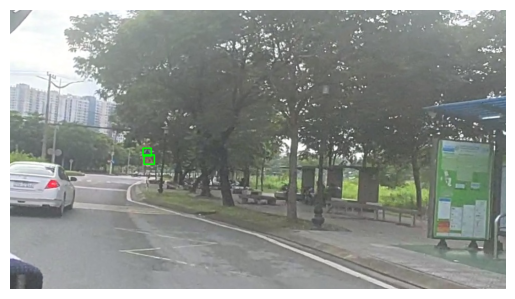

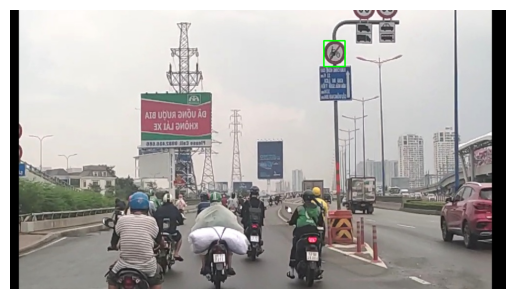

In [10]:
imgs = os.listdir(IMG_DIR)
sample = random.sample(imgs, 2)
for name in sample:
    img = cv2.imread(f"{IMG_DIR}/{name}")
    h,w = img.shape[:2]
    with open(f"{LBL_DIR}/{name.replace('.jpg','.txt')}") as f:
        lines = f.read().splitlines()
    for l in lines:
        c, xc, yc, bw, bh = map(float, l.split())
        x1, y1 = int((xc - bw/2) * w), int((yc - bh/2) * h)
        x2, y2 = int((xc + bw/2) * w), int((yc + bh/2) * h)
        cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


# 3. Model Training

In [11]:
model = YOLO("yolo11s.pt")

model.train(
    data="dataset_yolo/dataset.yaml",
    imgsz=832,
    epochs=70,
    batch=12,
    optimizer="AdamW",
    lr0=0.001,
    mosaic=0.3,
    close_mosaic=10,
    patience=15,
    device=0,
    verbose=False,
    workers=2,
    cache=True  
);

train: Caching images (8.1GB RAM): 100% ━━━━━━━━━━━━ 7486/7486 330.8it/s 22.6s
val: Caching images (0.3GB RAM): 100% ━━━━━━━━━━━━ 255/255 161.9it/s 1.6s


# 4. Evaluation

In [12]:
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

metrics = model.val(
    data="/kaggle/working/dataset_yolo/dataset.yaml",
    split="test",   
    imgsz=832,
    batch=8,
    plots=True      
)
print("mAP50-95: ", metrics.box.map)     
print("mAP50: ", metrics.box.map50)    
print("mean precision: ", metrics.box.mp)       
print("mean recall", metrics.box.mr)       

mAP50-95:  0.7972373698562684
mAP50:  0.9863434343811286
mean precision:  0.9596420245703361
mean recall 0.9773174496453567


# Inference Function

In [13]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. Load fine-tuned model
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

# 2. Inference function
def run_inference(image_path, conf=0.25):
    results = model.predict(
        source=image_path,
        conf=conf,
        save=False,
        verbose=False
    )

    # YOLO-rendered image (with boxes & labels)
    rendered_img = results[0].plot()

    # Display in notebook
    plt.figure(figsize=(10, 10))
    plt.imshow(rendered_img)
    plt.axis("off")
    plt.show()



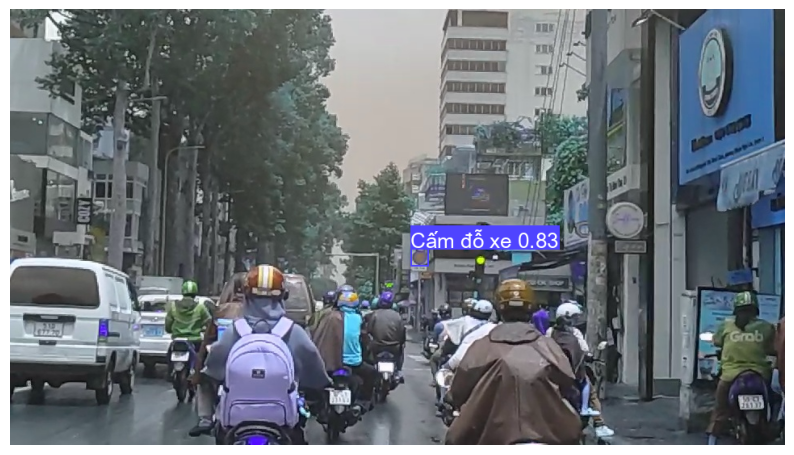

In [14]:
run_inference("/kaggle/input/vietnamese-traffic-signs/archive/images/0009.jpg")